This is a compilation of examples of uses of RSRS

In [1]:
from rsrs_config import RSRSBenchmarkConfig
import numpy as np
print(RSRSBenchmarkConfig.__init__.__doc__)


        Initialize RSRS Benchmark Configuration.

        Parameters
        ----------
        operator_type : int, optional
            Index selecting the structured operator type to use.
            Options include:
            0: BasicStructuredOperator (default)
            1: BemppClLaplaceSingleLayer
            2: BemppClHelmholtzSingleLayer
            3: KiFMMLaplaceOperator
            4: KiFMMHelmholtzOperator
            5: BemppRsLaplaceOperator
            6: BemppClLaplaceSingleLayerModified
            7: BemppClLaplaceSingleLayerPreconditioned
            8: BemppClLaplaceSingleLayerMMPreconditioned
            9: BemppClHelmholtzSingleLayerCP
            The choice affects the problem type and required parameters and more kernels can be addded in python/structured_operators.py

        precision : int, optional
            Index for numerical precision:
            0: Single precision (not fully enabled)
            1: Double precision (default)

        h : float,

In [ ]:
## Generate the test case either to run the test or retrieve results
## recommendations: if operator_type = 5, and if ref_level = 8, pick depth = 4 (this is a problem of around 500k dofs)
## if ref_level = 9, pick depth = 5 (this is a problem of around 2MM dofs)
#config = RSRSBenchmarkConfig(operator_type=5, dim_arg_type=3, ref_level=5, depth=3, min_level = 1, factors_cn = True, op_stabilisation=0.0001)
config = RSRSBenchmarkConfig(operator_type=9, dim_arg_type=0, min_level=1, kappa = 3*np.pi, factors_cn = False, dense_errors =False, rrqr=0, f=1.0)

h is 0.08333333333333333


In [7]:
## Generate the shell script (disable it unless you want to run the test)
config.generate_bash_script("run_test.sh")

In [4]:
## Running test in Rust

#!./run_test.sh

In [5]:
print("This problem has " + str(config.get_degrees_of_freedom()) + " degrees of freedom")

This problem has 8192 degrees of freedom


In [6]:
print(config.plot_errors_vs_tolerance.__doc__)


        Plot a specified error metric vs tolerance.

        Parameters
        ----------
        metric_index : int
            The index of the error metric to plot on the y-axis. Must be one of:
            1 - 'norm_2_error'
            2 - 'norm_2_error_inv'
            3 - 'app_condition_number'
            4 - 'tot_num_samples'
            5 - 'residual_size'
        logx : bool
            If True, use logarithmic scale for the x-axis (tolerance).
        logy : bool
            If True, use logarithmic scale for the y-axis (metric).

        Raises
        ------
        ValueError
            If `metric_index` is not in the range 1 to 5.
        


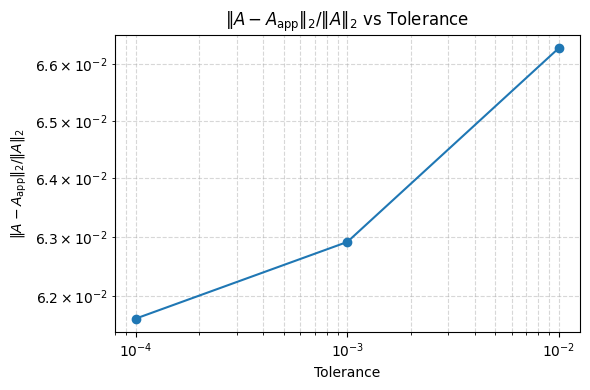

In [ ]:
config.plot_errors_vs_tolerance(1)

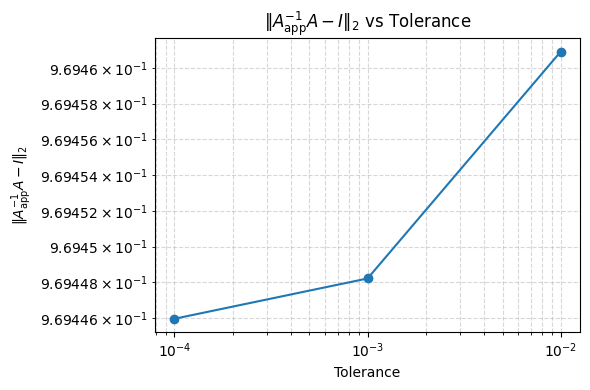

In [8]:
config.plot_errors_vs_tolerance(2)

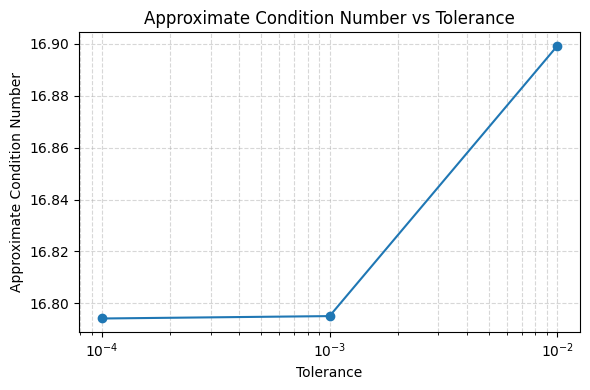

In [9]:
config.plot_errors_vs_tolerance(3, logy=False)

In [10]:
config.plot_errors_vs_tolerance(4, False)

[[0.0001, 0.001, 0.01], [995, 667, 464]]

In [11]:
config.plot_errors_vs_tolerance(5, False)

[[0.0001, 0.001, 0.01], [7594, 7847, 7958]]

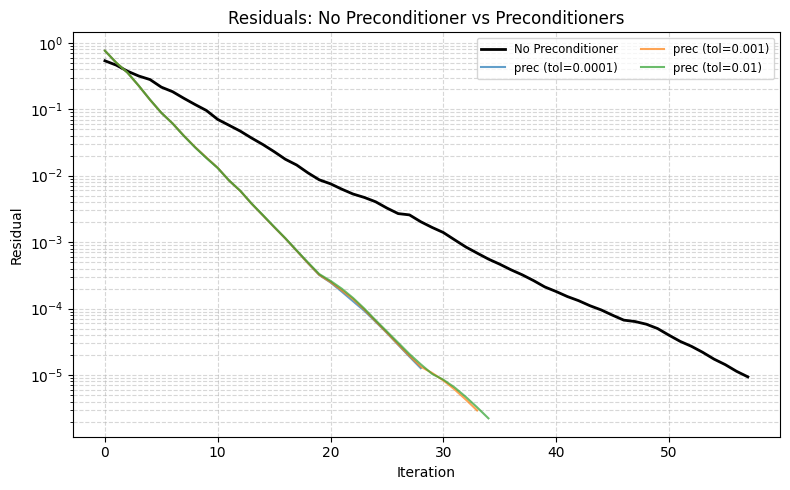

In [12]:
config.plot_gmres_residuals()

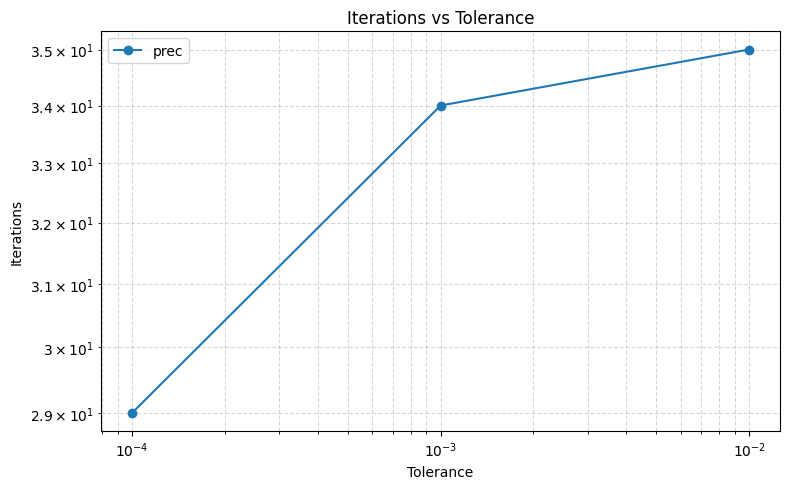

In [13]:
config.plot_residual_convergence()

In [14]:
print(config.plot_total_elapsed_time_vs_tolerance.__doc__)


        Plot total elapsed time without sampling vs tolerance (in seconds).

        Parameters
        ----------
        logx : bool, optional
            If True, use log scale on the x-axis (tolerance).
        logy : bool, optional
            If True, use log scale on the y-axis (time).
        


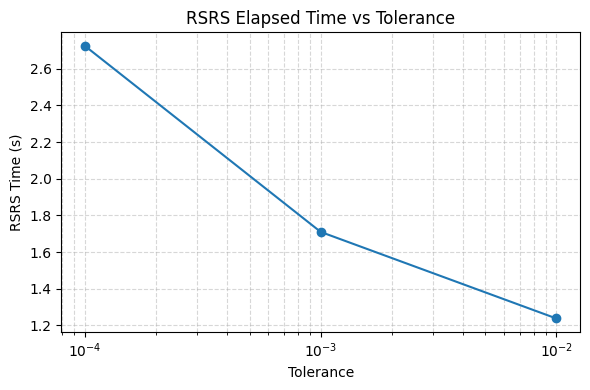

In [15]:
config.plot_total_elapsed_time_vs_tolerance(logy=False)

In [16]:
print(config.plot_time_breakdown_piecharts.__doc__)


        Plot a pie chart of time breakdown for each tolerance.

        Parameters
        ----------
        max_charts : int or None
            Maximum number of pie charts to display. If None, shows all.
        


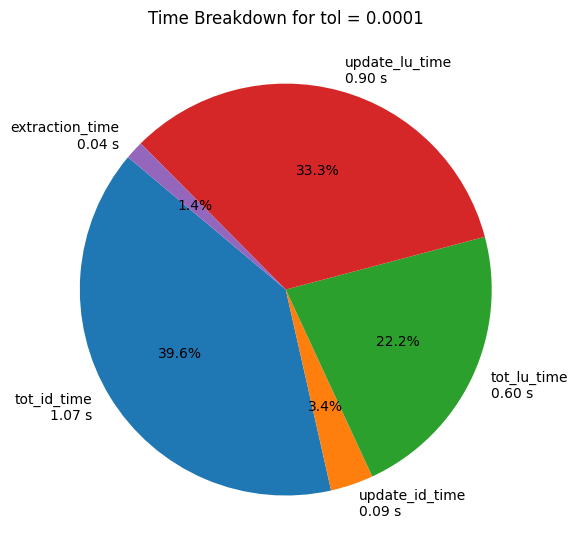

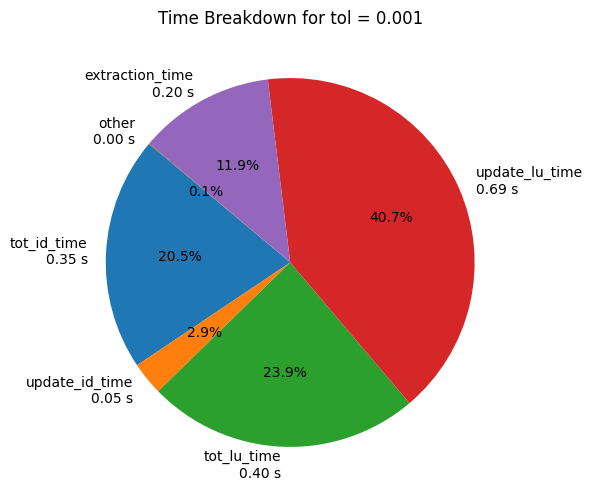

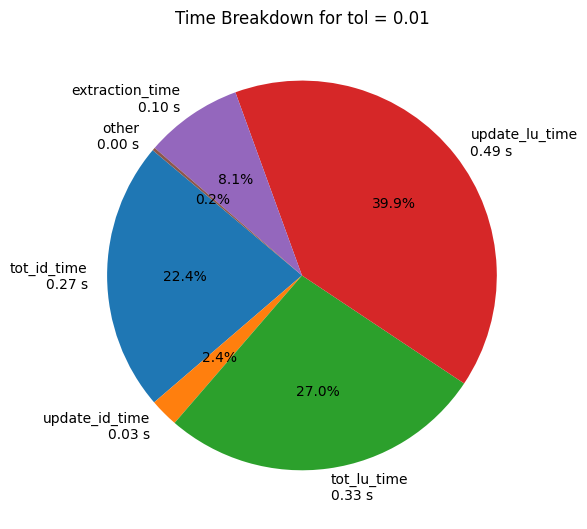

In [17]:
config.plot_time_breakdown_piecharts()

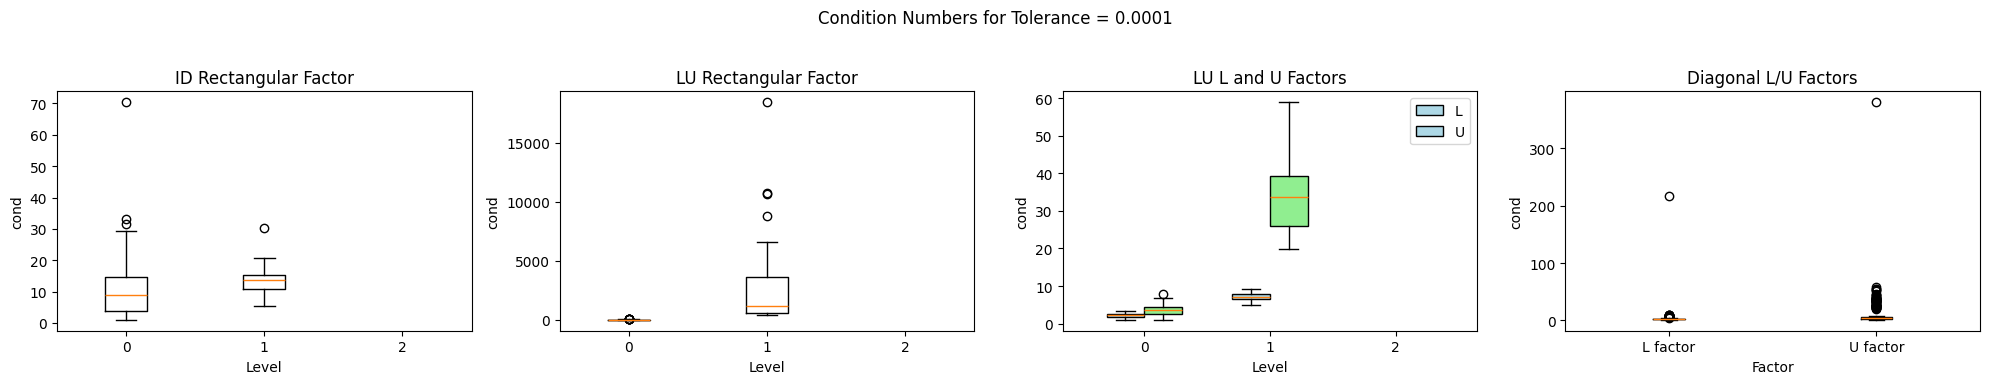

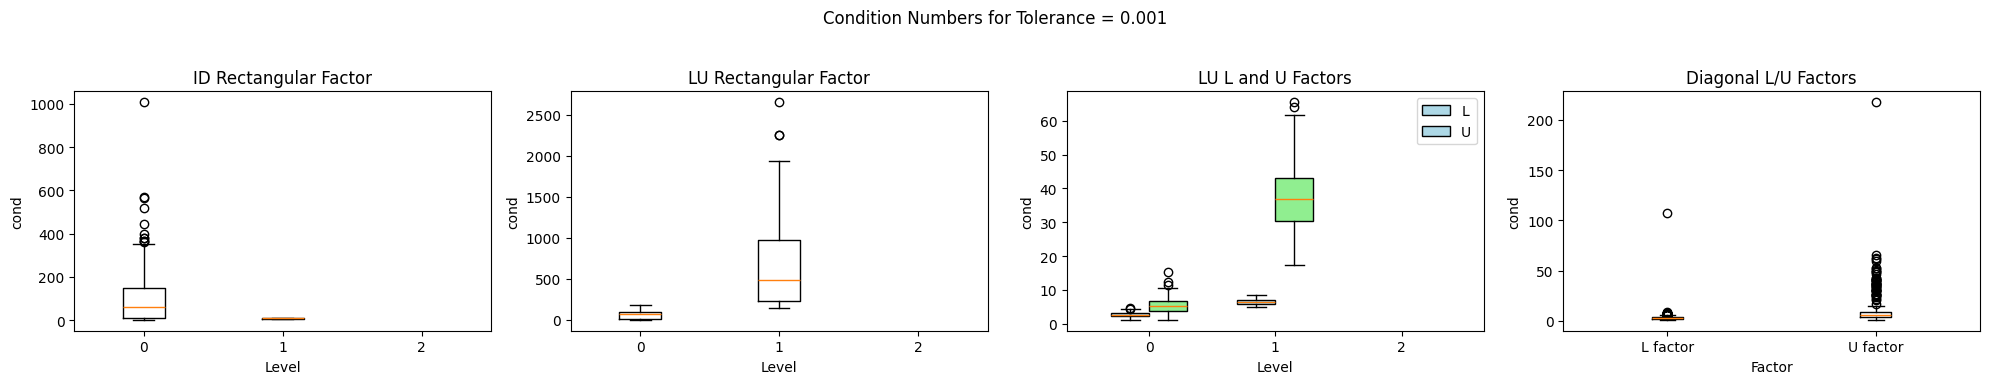

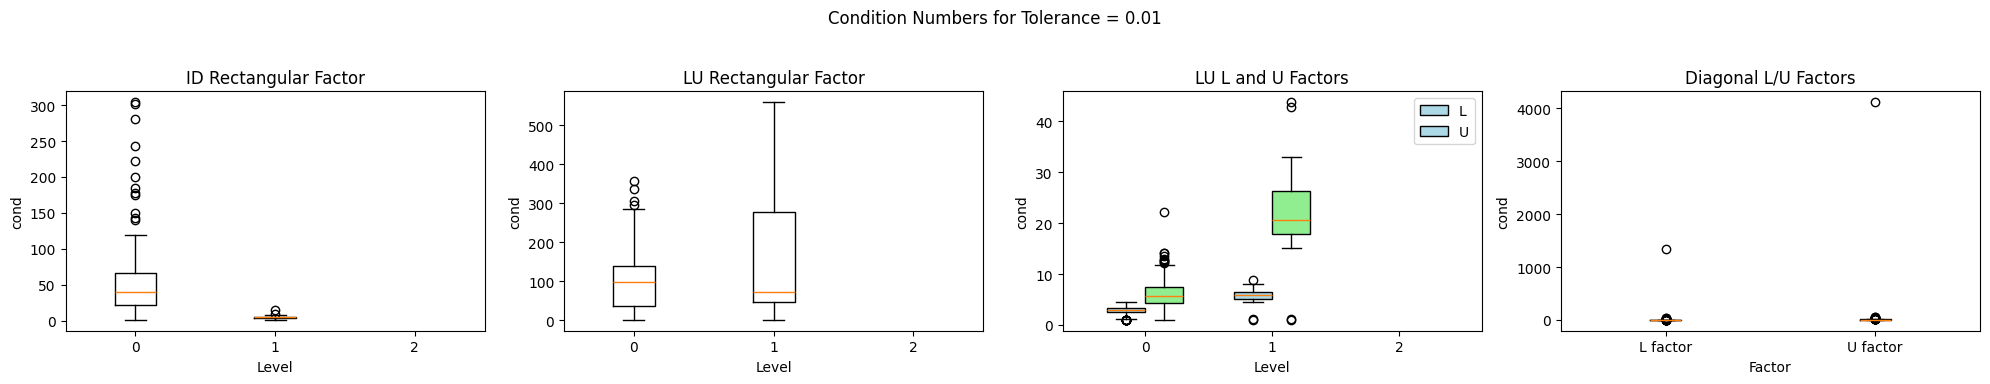

In [30]:
config.plot_factor_metrics(metric = "cond")

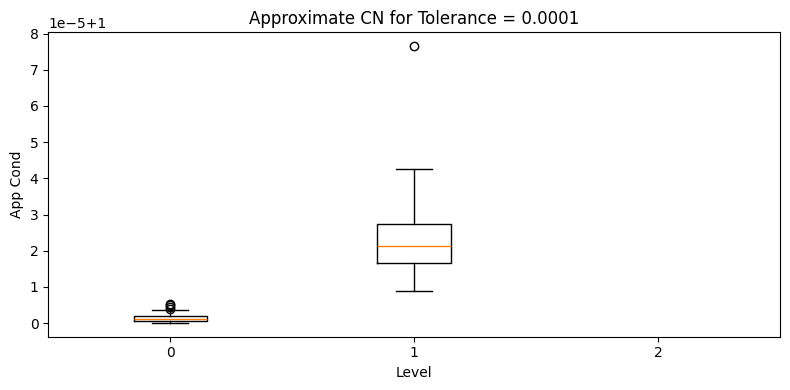

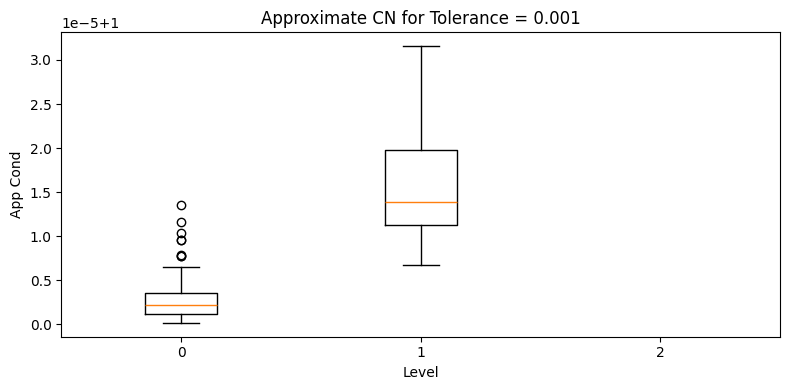

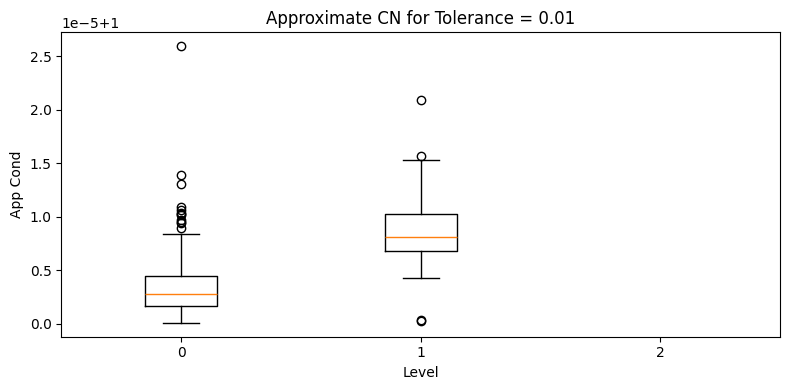

In [31]:
config.plot_lu_factors_app_cond()

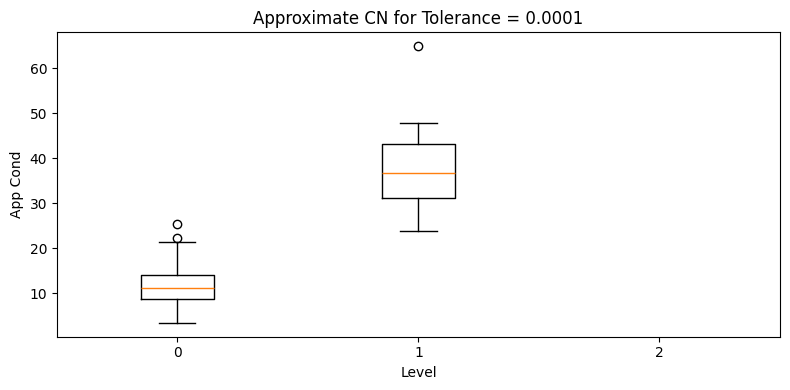

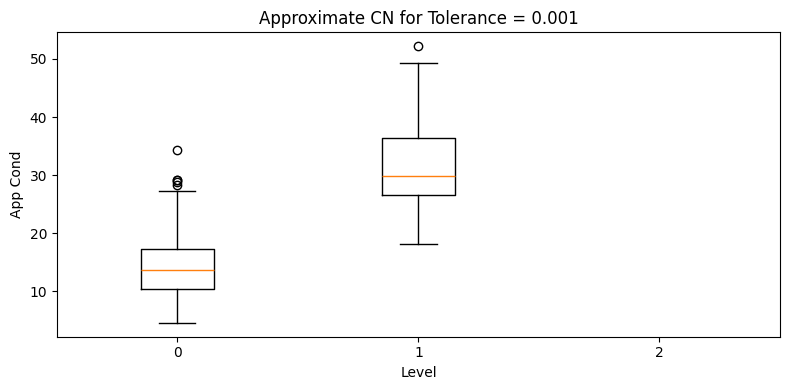

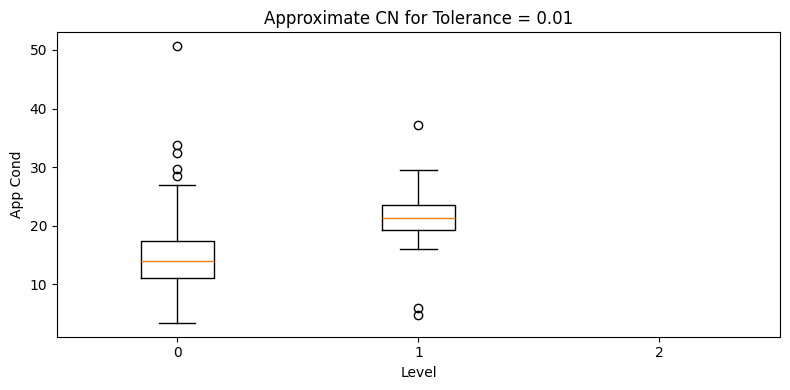

In [32]:
config.plot_id_factors_app_cond()

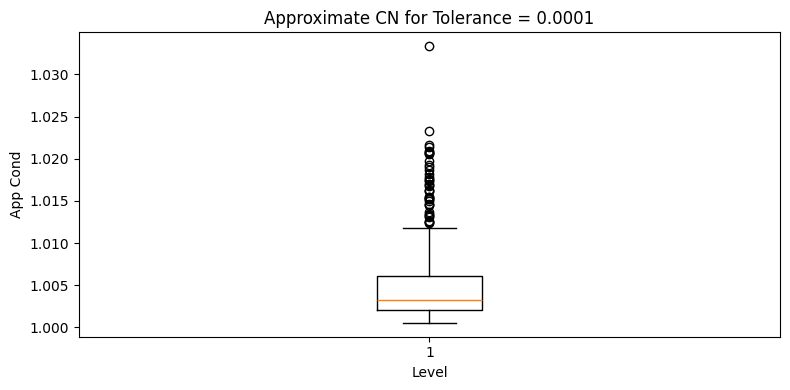

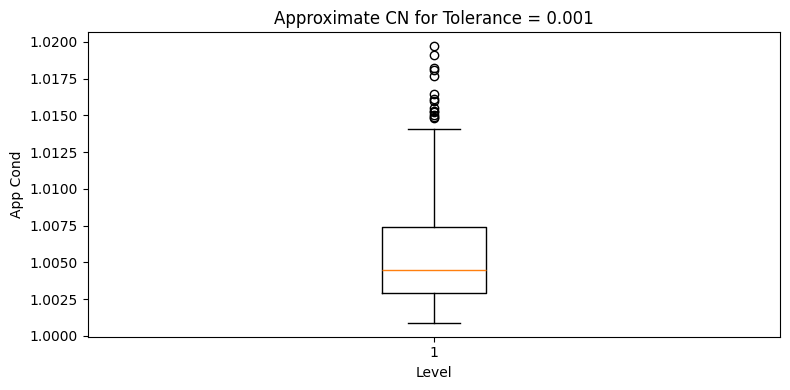

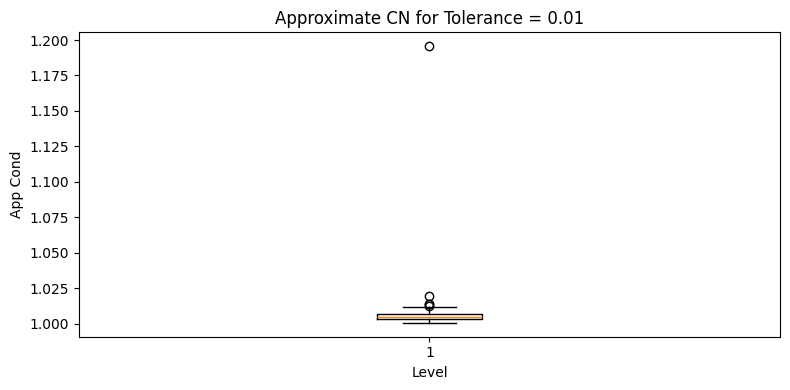

In [33]:
config.plot_d_factor_app_cond()

In [4]:
import bempp_cl.api
grid = bempp_cl.api.shapes.sphere(h=0.5)
domain = bempp_cl.api.function_space(grid, "DP", 0)
dual_to_range = domain
range = domain
mat = bempp_cl.api.operators.boundary.helmholtz.single_layer(
                domain, range, dual_to_range, np.pi).weak_form()

In [7]:
mat.to_dense()

array([[ 5.39579318e-03+1.78894497e-03j, -4.17903490e-05+1.02844246e-03j,
        -1.13138165e-04+9.47692034e-04j, ...,
         1.16061498e-04-1.05793444e-04j,  1.63857953e-04-4.53646504e-05j,
         1.47182183e-04-4.02653459e-05j],
       [-4.17903490e-05+1.02844246e-03j,  5.28918521e-03+1.74127930e-03j,
         1.88447389e-03+1.57185666e-03j, ...,
         1.35253400e-04-5.74990963e-05j,  1.46461139e-04-9.76080877e-05j,
         1.19464445e-04-1.09063734e-04j],
       [-1.13138165e-04+9.47692034e-04j,  1.88447496e-03+1.57185666e-03j,
         5.12222745e-03+1.66620217e-03j, ...,
         1.20325570e-04-8.83180359e-05j,  1.29408178e-04-1.20077350e-04j,
         1.04817371e-04-1.22659526e-04j],
       ...,
       [ 1.16061498e-04-1.05793444e-04j,  1.35253400e-04-5.74990963e-05j,
         1.20325570e-04-8.83180359e-05j, ...,
         1.78668333e-03+3.98821534e-04j, -1.26592819e-04+1.60169613e-04j,
        -1.39387305e-04+5.15714213e-05j],
       [ 1.63857953e-04-4.53646504e-05j,  1.

In [19]:
def is_hermitian_exact(A):
    return np.array_equal(A, A.T)

def is_hermitian(A, tol=1e-12):
    return np.allclose(A, A.T.conj(), atol=tol)


is_hermitian(mat.to_dense(), 1e-2)

True